In [1]:
import uproot
import ROOT as r
import mplhep
import matplotlib.pyplot as plt
import numpy as np
plt.style.use(mplhep.style.CMS)

Welcome to JupyROOT 6.28/11


In [2]:
f = uproot.open('fitDiagnosticsTest.root')

f.keys()

['shapes_prefit;1',
 'shapes_prefit/ptbin0ggffail2022;1',
 'shapes_prefit/ptbin0ggffail2022/data;1',
 'shapes_prefit/ptbin0ggffail2022/TTbar;1',
 'shapes_prefit/ptbin0ggffail2022/VBF;1',
 'shapes_prefit/ptbin0ggffail2022/W;1',
 'shapes_prefit/ptbin0ggffail2022/WH;1',
 'shapes_prefit/ptbin0ggffail2022/ZH;1',
 'shapes_prefit/ptbin0ggffail2022/ZJetsbb;1',
 'shapes_prefit/ptbin0ggffail2022/ZJetsqq;1',
 'shapes_prefit/ptbin0ggffail2022/ggF;1',
 'shapes_prefit/ptbin0ggffail2022/ttH;1',
 'shapes_prefit/ptbin0ggffail2022/qcd;1',
 'shapes_prefit/ptbin0ggffail2022/total;1',
 'shapes_prefit/ptbin0ggffail2022/total_signal;1',
 'shapes_prefit/ptbin0ggffail2022/total_background;1',
 'shapes_prefit/ptbin0ggffail2022/total_covar;1',
 'shapes_prefit/ptbin0ggfpass2022;1',
 'shapes_prefit/ptbin0ggfpass2022/data;1',
 'shapes_prefit/ptbin0ggfpass2022/TTbar;1',
 'shapes_prefit/ptbin0ggfpass2022/VBF;1',
 'shapes_prefit/ptbin0ggfpass2022/W;1',
 'shapes_prefit/ptbin0ggfpass2022/WH;1',
 'shapes_prefit/ptbin0ggf

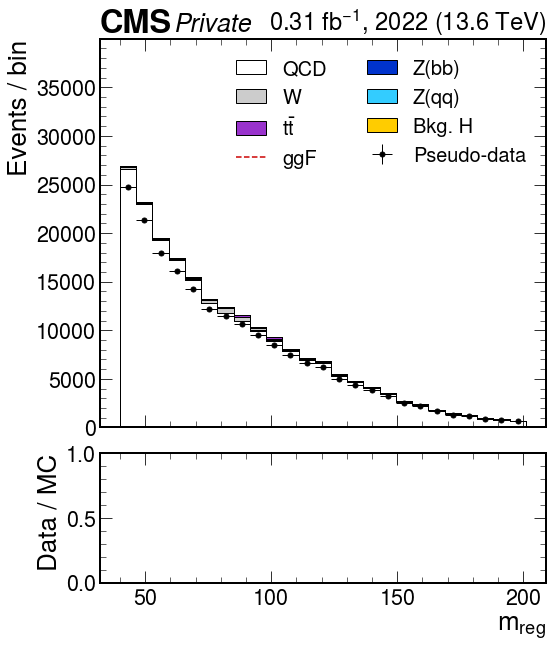

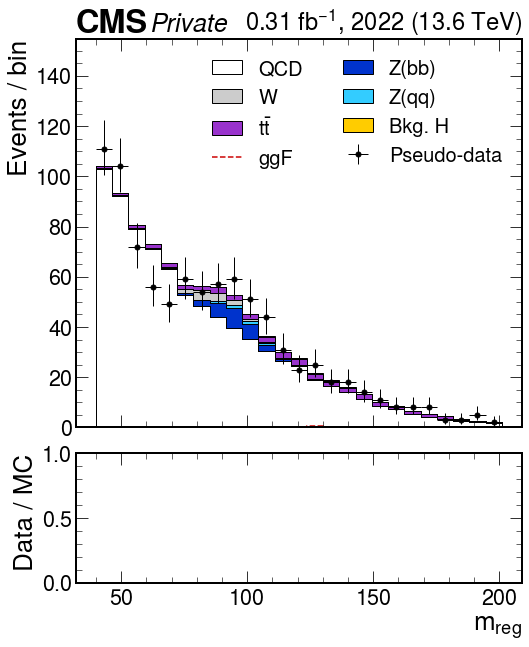

In [14]:
plt.style.use(mplhep.style.CMS)

colour = {
    "qcd" : "white",
    "ZJetsbb" : "#0033cc",
    "ZJetsqq" : "#33ccff",
    "W" : "#cccccc",
    "TTbar" : "#9933cc",
#     "Single t" : "#ff66cc",
#     "VV" : "#ff9900",
}

label = {
    "qcd" : "QCD",
    "ZJetsbb" : "Z(bb)",
    "ZJetsqq" : "Z(qq)",
    "W" : "W",
    "TTbar" : r"$t\bar{t}$",
    "Single t" : "Single t",
    "VV" : "#ff9900",
}

for reg in ['fail', 'pass']:
    
    hs = []
    labels = []
    colours = []

    fig, (ax, rax) = plt.subplots(
        2, 1, figsize=(8, 10), gridspec_kw={"height_ratios": (3, 1)}, sharex=True
    )
    fig.subplots_adjust(hspace=0.1)
    ax.set_ylabel("Events / bin")
    rax.set_ylabel("Data / MC")
    rax.set_xlabel(r"m$_{reg}$")
    ax.set_xlabel(" ")
    
    for process in colour.keys():

        h = f[f'shapes_fit_s/ptbin0ggf{reg}2022/{process}'].to_hist() * 7
        
        hs.append(h)
        labels.append(label[process])
        colours.append(colour[process])
        
    higgs_h = None
    
    for process in ['VBF', 'ZH', 'WH', 'ttH']:

        h = f[f'shapes_fit_s/ptbin0ggf{reg}2022/{process}'].to_hist() * 7
        
        if not higgs_h:
            higgs_h = h
        else:
            higgs_h += h
        
    hs.append(higgs_h)
    labels.append("Bkg. H")
    colours.append("#ffcc00")
    
    mplhep.histplot(
        hs,
        ax=ax,
        label=labels,
        stack=True,
        color=colours,
        histtype="fill",
        edgecolor="black",
        linewidth=1,
        flow="none",
    )
    
    h = f[f'shapes_fit_s/ptbin0ggf{reg}2022/ggF'].to_hist() * 7
    
    mplhep.histplot(
        h, 
        ax=ax,
        yerr=False,
        color="#cc0000",
        label=f"ggF",
        linestyle="dashed",
        flow="none",
    )
    
#     h = f[f'shapes_fit_s/ptbin0ggf{reg}2022/data']
    
    data = uproot.open("signalregion.root")
    h_data = data[f'ggf_{reg}_pt1_data_nominal'].to_hist()
    
    mplhep.histplot(
        h_data, 
        ax=ax, 
        histtype="errorbar",
        xerr=True,
        c="black",
        label=f"Pseudo-data",
        flow="none",
    )
    
#     ax.errorbar(
#         h.values(axis=0),
#         h.values(axis=1),
#         xerr=[
#             h.errors(which="low", axis=0),
#             h.errors(which="high", axis=0),
#         ], 
#         yerr=[
#             h.errors(which="low", axis=1),
#             h.errors(which="high", axis=1),
#         ],
#         fmt='o',
#         c='k',
#         label=f"Pseudo-data")
    
    hs_mc = f[f'shapes_fit_s/ptbin0ggf{reg}2022/total_background'].to_hist() * 7
    
    from uncertainties import unumpy
#     data = unumpy.uarray(h.values(axis=1), [h.errors(which="low", axis=1), h.errors(which="high", axis=1)])
    data =  unumpy.uarray(h_data.values(), h_data.variances())
    mc =  unumpy.uarray(hs_mc.values(), hs_mc.variances())
    ratio = data/mc

#     rax.errorbar(h_data.values(),
#          unumpy.nominal_values(ratio)[0],
#          yerr=unumpy.std_devs(ratio),
# #          xerr=[
# #             h.errors(which="low", axis=0),
# #             h.errors(which="high", axis=0),
# #          ],
#          fmt='o',
#          color='black'
#     )

    rax.axhline(1, color='gray',ls='--')
    
    mplhep.cms.label(
        ax=ax, 
        data=True, 
        fontsize=25,
        label="Private",
        year=2022,
        lumi=f"{0.31:.2f}",
        com=13.6,
    )
    
    handles, labels = ax.get_legend_handles_labels()
    order = [0, 3, 4, 6, 1, 2, 5, 7]
    ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], fontsize=20, ncols=2)
    
    ax.set_ylim(0, max(hs[0].values()) * 1.5)

In [12]:
h_data.values()

array([24793., 21353., 17966., 16063., 14271., 12151., 11442., 10628.,
        9546.,  8521.,  7462.,  6592.,  6260.,  5019.,  4420.,  3864.,
        3228.,  2509.,  2209.,  1697.,  1334.,  1167.,   866.,   769.,
         656.])

In [13]:
unumpy.nominal_values(ratio)[0]

0.9200069413544782